# 01 — Market Data Analysis

Explore the 97 tickers fetched by the data pipeline.  
Covers: price distributions, volatility profiles, correlation heatmap, sector breakdown.

**Run `python -m data.initializer --skip-news` first.**

In [5]:
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('../backend').resolve()))

# ── style ──
plt.style.use('dark_background')
PALETTE = {'large': '#58a6ff', 'mid': '#f0e68c', 'small': '#f85149'}
plt.rcParams.update({'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
                      'axes.edgecolor': '#30363d', 'grid.color': '#21262d',
                      'text.color': '#e6edf3', 'axes.labelcolor': '#8b949e',
                      'xtick.color': '#8b949e', 'ytick.color': '#8b949e',
                      'font.family': 'monospace'})
print('Imports OK')

Imports OK


In [6]:
# ── Load feature parquets ──────────────────────────────────────────────────
PROCESSED = Path('../backend/stock_data/processed')

dfs = []
for tier in ('large', 'mid', 'small'):
    p = PROCESSED / f'{tier}_cap_features.parquet'
    if p.exists():
        df = pd.read_parquet(p)
        df['cap_tier'] = tier
        dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
data['date'] = pd.to_datetime(data.index if 'date' not in data.columns else data['date'])
print(f'Loaded {len(data):,} rows across {data["ticker"].nunique()} tickers')
print(f'Date range: {data["date"].min().date()} → {data["date"].max().date()}')
data.head()

Loaded 48,402 rows across 97 tickers
Date range: 1970-01-01 → 1970-01-01


,open,high,low,close,volume,returns,log_returns,range_pct,ticker,cap_tier,source,volatility_20d,sma_20,sma_50,rsi_14,volume_ratio,gap_pct,date
0,169.676,169.854,167.315,167.752,69147208.0,-0.005879,-0.005896,0.015135,AAPL,large,stooq,NaN,NaN,NaN,NaN,NaN,0.005523,1970-01-01 00:00:00.000000000
1,588.350,598.350,585.810,591.500,1886807.0,0.011786,0.011717,0.021200,TMO,large,stooq,NaN,NaN,NaN,NaN,NaN,0.006397,1970-01-01 00:00:00.000000001
2,118.600,119.580,118.420,119.340,3388820.0,0.007259,0.007232,0.009720,ABT,large,stooq,NaN,NaN,NaN,NaN,NaN,0.001013,1970-01-01 00:00:00.000000002
3,179.990,181.576,173.700,176.540,107920944.0,-0.023238,-0.023512,0.044613,TSLA,large,stooq,NaN,NaN,NaN,NaN,NaN,-0.004150,1970-01-01 00:00:00.000000003
4,52.340,53.810,52.250,53.380,21692324.0,0.030104,0.029660,0.029224,BMY,large,stooq,NaN,NaN,NaN,NaN,NaN,0.010035,1970-01-01 00:00:00.000000004


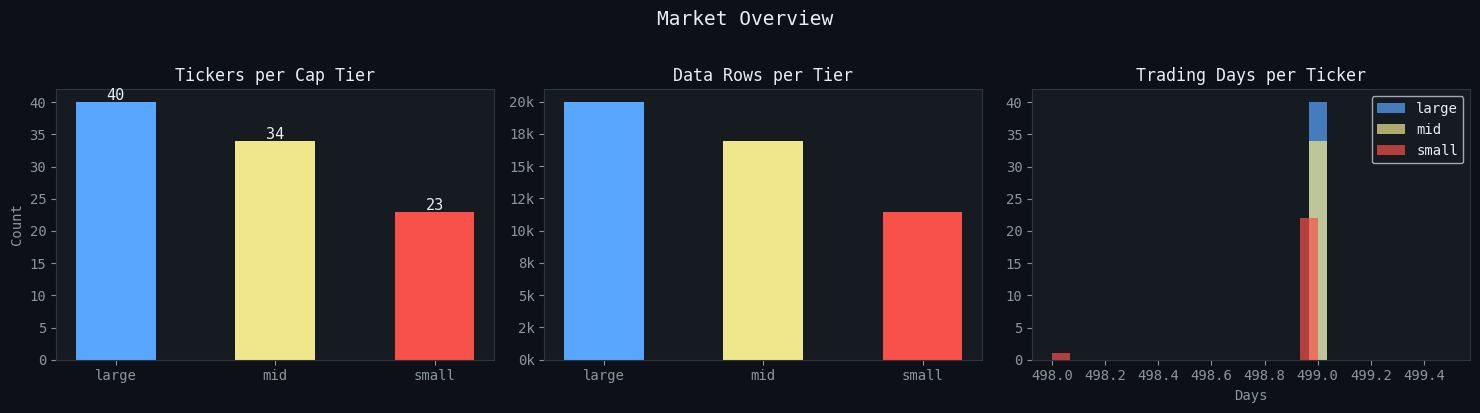

In [7]:
# ── 1. Ticker count by cap tier ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Market Overview', fontsize=14, y=1.02)

# Count by tier
tier_counts = data.groupby('cap_tier')['ticker'].nunique()
colors = [PALETTE[t] for t in tier_counts.index]
axes[0].bar(tier_counts.index, tier_counts.values, color=colors, width=0.5)
axes[0].set_title('Tickers per Cap Tier')
axes[0].set_ylabel('Count')
for i, (k, v) in enumerate(tier_counts.items()):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontsize=11)

# Row count by tier
row_counts = data.groupby('cap_tier').size()
colors2 = [PALETTE[t] for t in row_counts.index]
axes[1].bar(row_counts.index, row_counts.values, color=colors2, width=0.5)
axes[1].set_title('Data Rows per Tier')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

# Trading days per ticker (median)
days = data.groupby(['ticker','cap_tier']).size().reset_index(name='days')
for tier, grp in days.groupby('cap_tier'):
    axes[2].hist(grp['days'], alpha=0.7, label=tier, color=PALETTE[tier], bins=15)
axes[2].set_title('Trading Days per Ticker')
axes[2].set_xlabel('Days')
axes[2].legend()

plt.tight_layout()
plt.savefig('01_market_overview.png', dpi=120, bbox_inches='tight')
plt.show()

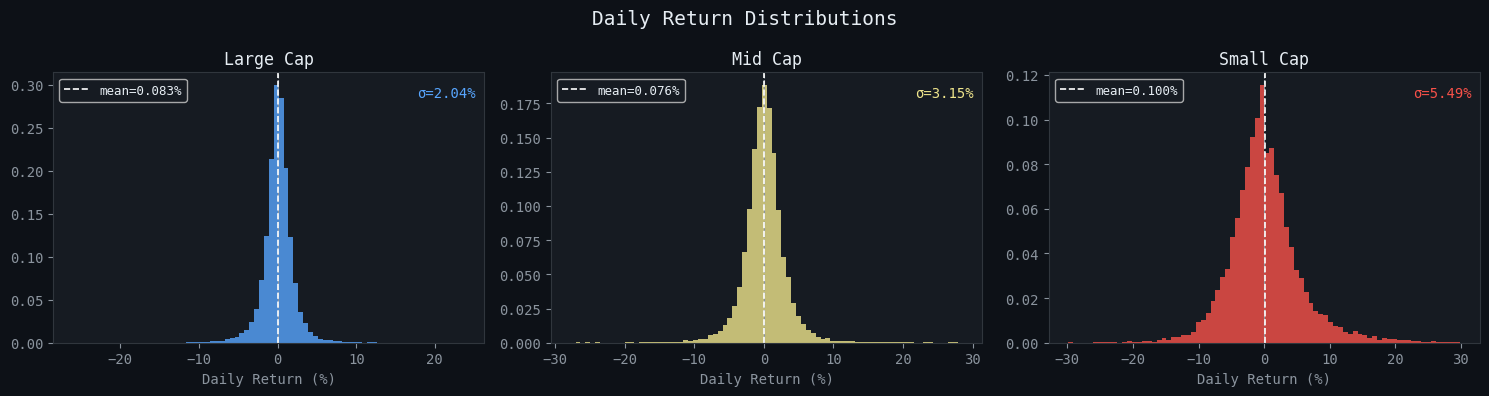

In [8]:
# ── 2. Return distributions by tier ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Daily Return Distributions', fontsize=14)

for ax, tier in zip(axes, ['large', 'mid', 'small']):
    returns = data[data['cap_tier'] == tier]['returns'].dropna()
    returns = returns[(returns > -0.3) & (returns < 0.3)]  # clip outliers for display
    ax.hist(returns * 100, bins=80, color=PALETTE[tier], alpha=0.8, density=True)
    ax.axvline(0, color='#8b949e', lw=0.8, ls='--')
    ax.axvline(returns.mean() * 100, color='white', lw=1.2, ls='--', label=f'mean={returns.mean()*100:.3f}%')
    ax.set_title(f'{tier.capitalize()} Cap')
    ax.set_xlabel('Daily Return (%)')
    ax.legend(fontsize=9)
    mu, std = returns.mean()*100, returns.std()*100
    ax.text(0.98, 0.95, f'σ={std:.2f}%', transform=ax.transAxes,
            ha='right', va='top', fontsize=10, color=PALETTE[tier])

plt.tight_layout()
plt.savefig('01_return_distributions.png', dpi=120, bbox_inches='tight')
plt.show()

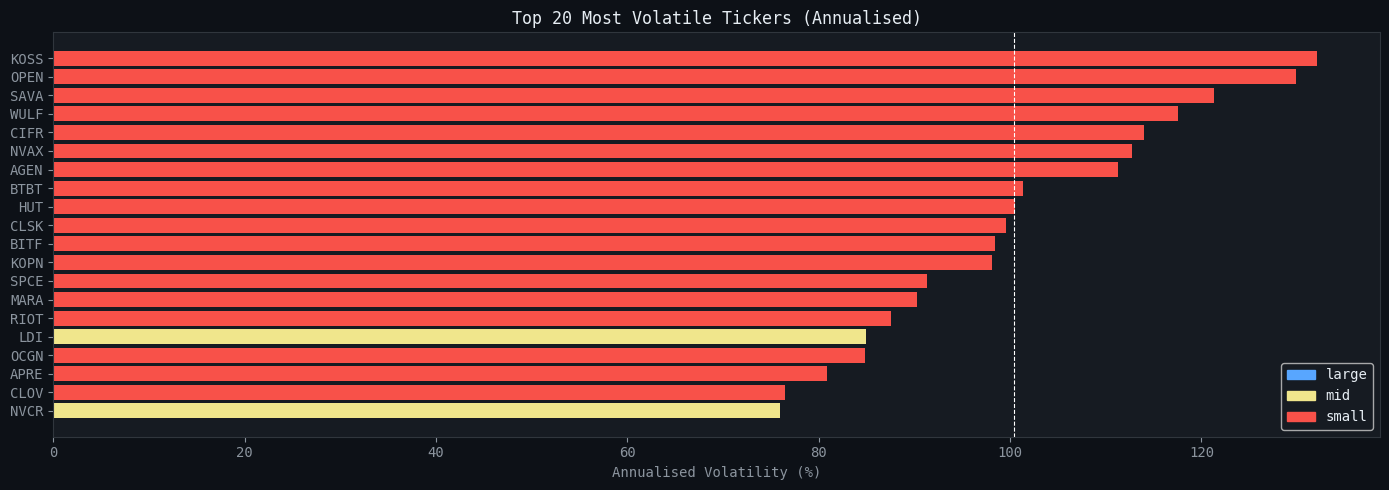

ticker cap_tier  annual_vol
  KOSS    small  132.052114
  OPEN    small  129.888061
  SAVA    small  121.279261
  WULF    small  117.584546
  CIFR    small  113.971681
  NVAX    small  112.763330
  AGEN    small  111.271584
  BTBT    small  101.379829
   HUT    small  100.489139
  CLSK    small   99.538186
  BITF    small   98.455351
  KOPN    small   98.141813
  SPCE    small   91.318824
  MARA    small   90.317513
  RIOT    small   87.551561
   LDI      mid   84.976537
  OCGN    small   84.837075
  APRE    small   80.888542
  CLOV    small   76.423181
  NVCR      mid   75.982745


In [9]:
# ── 3. Volatility profiles — top 20 most volatile tickers ─────────────────
vol_by_ticker = (data.groupby(['ticker','cap_tier'])['returns']
                 .std() * np.sqrt(252) * 100
                 .reset_index(name='annual_vol') if False else
                 data.groupby(['ticker','cap_tier'])['returns']
                 .std().mul(np.sqrt(252)).mul(100)
                 .reset_index(name='annual_vol'))

top20 = vol_by_ticker.nlargest(20, 'annual_vol')
colors = [PALETTE[t] for t in top20['cap_tier']]

fig, ax = plt.subplots(figsize=(14, 5))
bars = ax.barh(top20['ticker'], top20['annual_vol'], color=colors)
ax.set_xlabel('Annualised Volatility (%)')
ax.set_title('Top 20 Most Volatile Tickers (Annualised)')
ax.invert_yaxis()
ax.axvline(top20['annual_vol'].mean(), color='white', ls='--', lw=0.8, label='Mean')

# legend
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=v, label=k) for k, v in PALETTE.items()], loc='lower right')

plt.tight_layout()
plt.savefig('01_volatility_profiles.png', dpi=120, bbox_inches='tight')
plt.show()
print(top20.to_string(index=False))

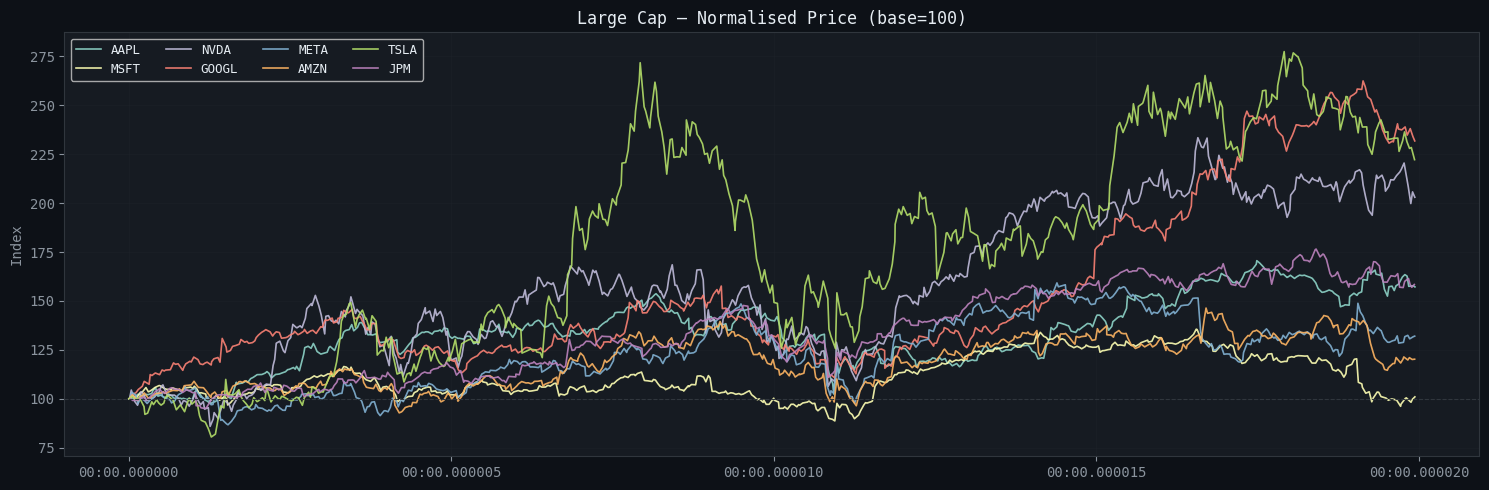

In [10]:
# ── 4. Price series — large cap ────────────────────────────────────────────
large_tickers = ['AAPL', 'MSFT', 'NVDA', 'GOOGL', 'META', 'AMZN', 'TSLA', 'JPM']
large_tickers = [t for t in large_tickers if t in data['ticker'].unique()]

fig, ax = plt.subplots(figsize=(15, 5))
for i, ticker in enumerate(large_tickers):
    df_t = data[data['ticker'] == ticker].sort_values('date')
    # Normalise to 100
    norm = df_t['close'] / df_t['close'].iloc[0] * 100
    ax.plot(df_t['date'], norm, lw=1.2, label=ticker, alpha=0.9)

ax.axhline(100, color='#30363d', lw=0.8, ls='--')
ax.set_title('Large Cap — Normalised Price (base=100)')
ax.set_ylabel('Index')
ax.legend(ncol=4, fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('01_large_cap_prices.png', dpi=120, bbox_inches='tight')
plt.show()

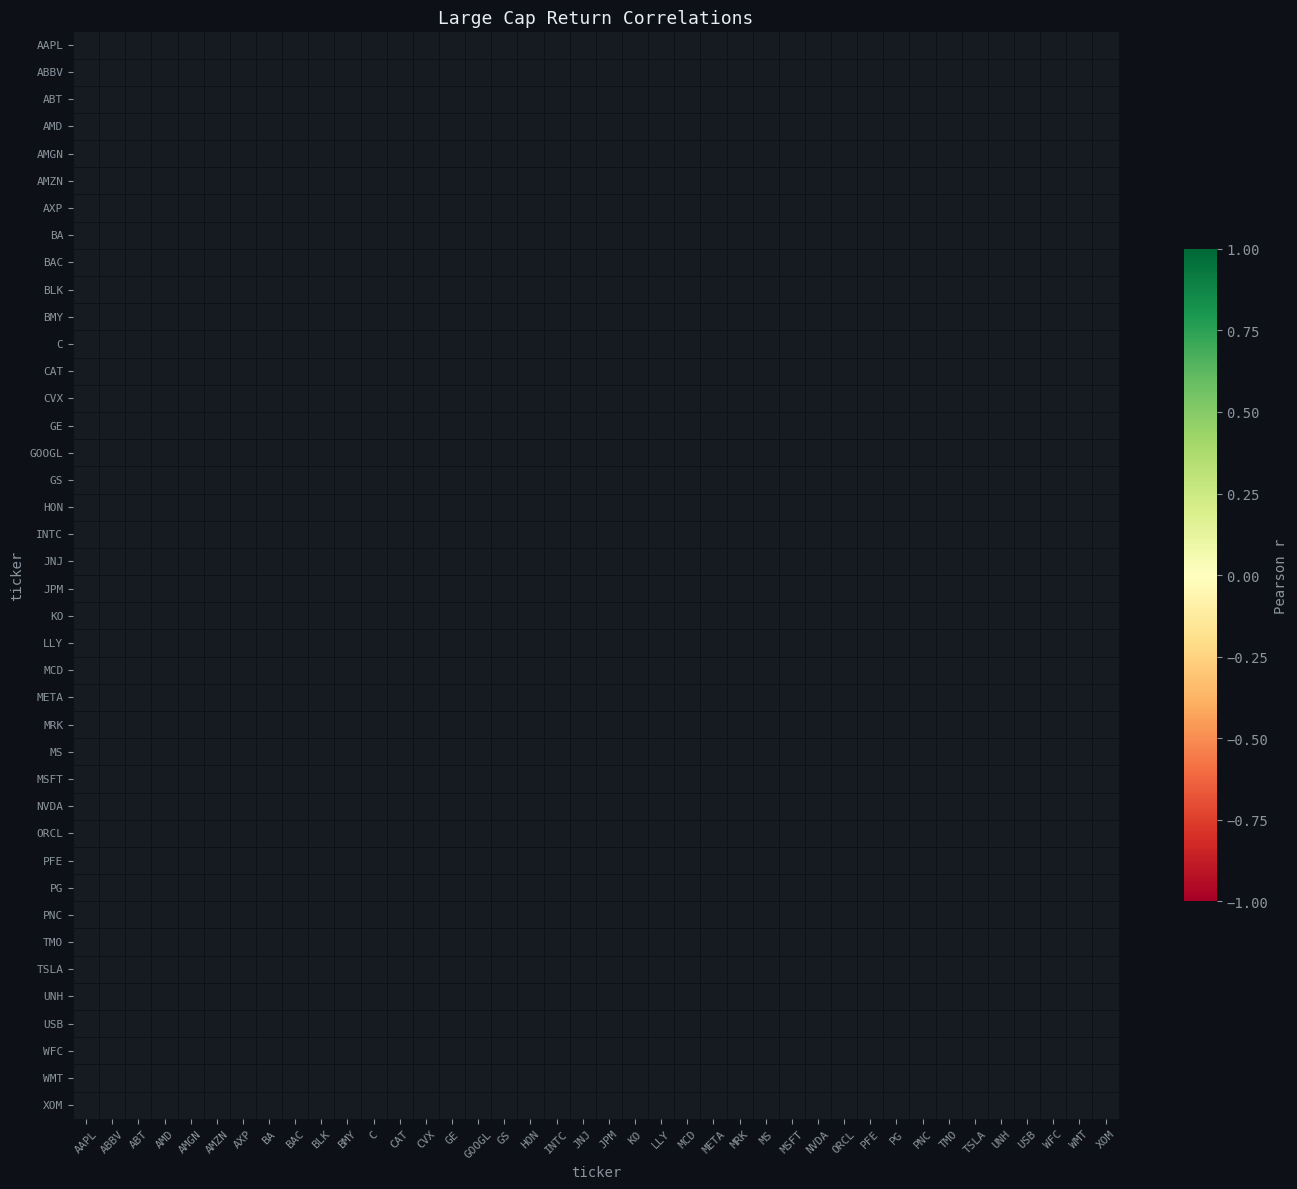

Top 5 most correlated pairs:
Empty DataFrame
Columns: [A, B, corr]
Index: []

Top 5 least correlated pairs:
Empty DataFrame
Columns: [A, B, corr]
Index: []


In [13]:
# ── 5. Correlation heatmap — large cap returns ─────────────────────────────
pivot = (data[data['cap_tier'] == 'large']
         .pivot_table(index='date', columns='ticker', values='returns'))
corr = pivot.corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, fmt='.1f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.4, linecolor='#0d1117',
            cbar_kws={'shrink': 0.6, 'label': 'Pearson r'},
            ax=ax)
ax.set_title('Large Cap Return Correlations', fontsize=13)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
plt.savefig('01_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

# Most correlated pairs
stacked = corr.where(~mask).stack()
stacked.index.names = ['A', 'B']
corr_pairs = stacked.reset_index()
corr_pairs.columns = ['A', 'B', 'corr']
corr_pairs = corr_pairs.sort_values('corr', ascending=False)
print('Top 5 most correlated pairs:')
print(corr_pairs.head())
print('\nTop 5 least correlated pairs:')
print(corr_pairs.tail())

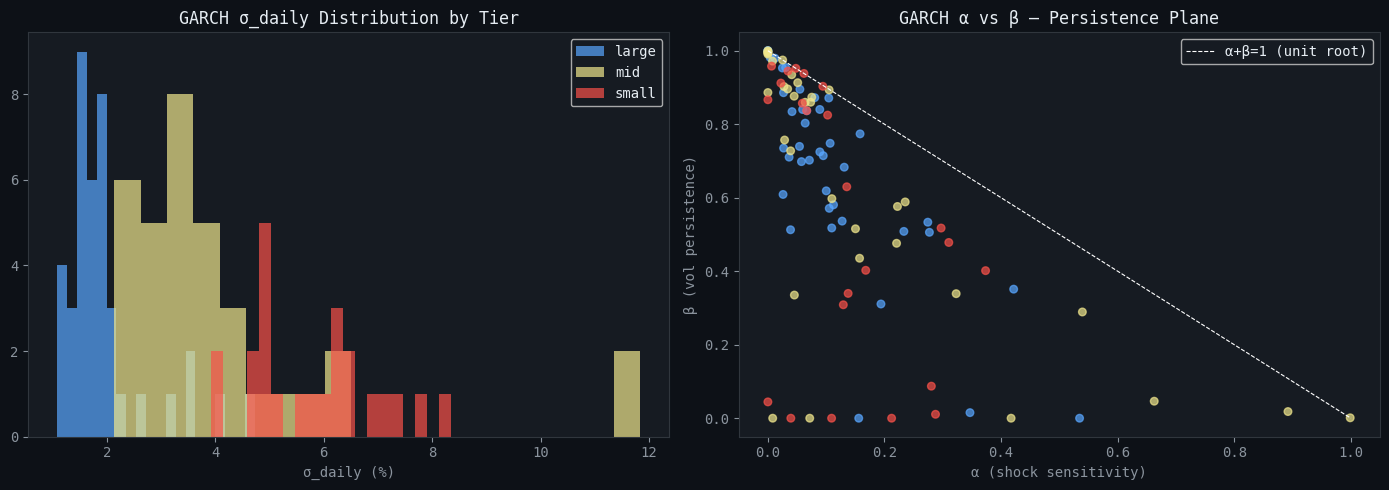

ticker cap_tier  sigma_daily        alpha     beta  persistence
  DDOG      mid     0.118382 0.000000e+00 0.999816     0.999816
  PFSI      mid     0.115969 1.050165e-01 0.893389     0.998405
  SAVA    small     0.083542 2.971277e-01 0.517452     0.814580
  AGEN    small     0.078560 3.103089e-01 0.478208     0.788517
  WULF    small     0.073996 1.549506e-10 0.044398     0.044398
  CIFR    small     0.070647 3.019838e-11 0.866612     0.866612
  NVAX    small     0.068926 3.936227e-02 0.000000     0.039362
  BTBT    small     0.064582 1.293785e-01 0.308701     0.438080
  SPCE    small     0.064221 3.734020e-01 0.401535     0.774937
    RH      mid     0.063770 6.627044e-01 0.046245     0.708950


In [15]:
# ── 6. GARCH vol params summary ────────────────────────────────────────────
with open('../backend/stock_data/volatility_params.json') as f:
    vol_params = json.load(f)

vdf = pd.DataFrame(vol_params).T.reset_index().rename(columns={'index': 'ticker'})
vdf['sigma_daily'] = pd.to_numeric(vdf['sigma_daily'], errors='coerce')
vdf = vdf.dropna(subset=['sigma_daily'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# sigma_daily by tier
for tier, grp in vdf.groupby('cap_tier'):
    axes[0].hist(grp['sigma_daily'] * 100, bins=20,
                 alpha=0.7, label=tier, color=PALETTE.get(tier, 'grey'))
axes[0].set_title('GARCH σ_daily Distribution by Tier')
axes[0].set_xlabel('σ_daily (%)')
axes[0].legend()

# alpha + beta (persistence)
vdf['alpha'] = pd.to_numeric(vdf['alpha'], errors='coerce')
vdf['beta']  = pd.to_numeric(vdf['beta'],  errors='coerce')
vdf['persistence'] = vdf['alpha'] + vdf['beta']
axes[1].scatter(vdf['alpha'], vdf['beta'],
                c=[PALETTE.get(t, 'grey') for t in vdf['cap_tier']],
                alpha=0.7, s=30)
axes[1].plot([0, 1], [1, 0], 'w--', lw=0.8, label='α+β=1 (unit root)')
axes[1].set_xlabel('α (shock sensitivity)')
axes[1].set_ylabel('β (vol persistence)')
axes[1].set_title('GARCH α vs β — Persistence Plane')
axes[1].legend()

plt.tight_layout()
plt.savefig('01_garch_params.png', dpi=120, bbox_inches='tight')
plt.show()
print(vdf[['ticker','cap_tier','sigma_daily','alpha','beta','persistence']]
      .sort_values('sigma_daily', ascending=False).head(10).to_string(index=False))